# Model training — reviewer-feedback response, part 3 (directional error breakdown)

This notebook answers a specific follow-up question: for **every** model and baseline
evaluated in Part 1 and Part 2, what does the error look like broken down by
upwind / crosswind / downwind flight — under **two different conventions** for what
"downwind" means, since the bioRxiv manuscript's exact wording is ambiguous between
them:

> "...a heavy tail driven by a subset of trajectories where heading is poorly
> constrained by the available features alone (often during portions of a trajectory
> where flies were headed downwind)."

- **Convention A — true heading.** "Headed downwind" = the fly's *body orientation*
  (the paper's actual target variable) points downwind. This is the more literal
  reading, and it lines up with a real mechanism: airspeed = groundspeed - windspeed,
  so a fly moving downwind near windspeed has airspeed close to zero, making
  `airspeed_angle` (a ratio of near-zero vector components) numerically degenerate -
  a natural reason heading would become "poorly constrained" specifically when the fly
  is oriented downwind.
- **Convention B — direction of travel.** "Headed downwind" = the fly's *groundspeed
  direction* is downwind (what Part 2's stratification used).

Both conventions bin each frame into upwind / crosswind / downwind using the same
+-45 degree bands, following the coordinate convention in `CLAUDE.md`
(positive x = upwind, wind blows toward -x).

No new models are trained here - every prediction reuses models and fits already
produced by Part 1 and Part 2. This notebook only adds the directional slicing.

**Why:** Reviewer #1 (major comment 7) asks directly for this: "Performance should also
be reported separately for each speed and for upwind, crosswind, and downwind flight.
The manuscript already observes that errors are concentrated in downwind segments; this
should be quantified rather than discussed only qualitatively." Part 2, Section 5
quantified this for `model_full` alone; this notebook extends it to every model and
baseline evaluated anywhere in this response, under both plausible readings of what the
manuscript means by "downwind."

## 1. Setup — reload split, trained models, and the OLS training data

In [1]:
import os
import sys
import random
from itertools import combinations

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    pull_out_individual_trajectories,
    augment_with_time_delay_embedding,
    naive_heading_correction,
    convex_opt_heading_correction,
    circular_distance,
    compute as heading_compute,
)

import keras

RESPONSE_DIR = '../pipelinedata/reviewer_response'
os.makedirs(RESPONSE_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TIME_WINDOW = 4
input_names_full = ['groundspeed', 'groundspeed_angle',
                     'airspeed', 'airspeed_angle',
                     'thrust', 'thrust_angle']
input_names_ablated = ['groundspeed', 'groundspeed_angle',
                        'airspeed', 'airspeed_angle']
n_input_full = len(input_names_full) * TIME_WINDOW
n_input_ablated = len(input_names_ablated) * TIME_WINDOW
n_input_w1 = len(input_names_full) * 1
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed(trajectories, input_names, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=input_names,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(
        trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs
    )


final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

split_record = pd.read_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv')
train_ids = set(split_record.loc[split_record['split'] == 'train', 'trajec_objid'])
test_ids = set(split_record.loc[split_record['split'] == 'test', 'trajec_objid'])

train_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in train_ids]
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]
print(f"Reloaded split: {len(train_trajectories)} train / {len(test_trajectories)} test trajectories")

train_original_full = embed(train_trajectories, input_names_full, TIME_WINDOW, wind_augment=False)
test_embedded_full = embed(test_trajectories, input_names_full, TIME_WINDOW, wind_augment=False)
test_embedded_abl = embed(test_trajectories, input_names_ablated, TIME_WINDOW, wind_augment=False)
test_embedded_w1 = embed(test_trajectories, input_names_full, time_window=1, wind_augment=False)

model_full = keras.models.load_model('../models/model_reviewer_response_full.keras', safe_mode=False)
model_abl = keras.models.load_model('../models/model_reviewer_response_thrust_ablated.keras', safe_mode=False)
model_no_aug = keras.models.load_model('../models/model_reviewer_response_no_augmentation.keras', safe_mode=False)
model_no_embed = keras.models.load_model('../models/model_reviewer_response_no_time_delay.keras', safe_mode=False)
print("Loaded 4 ANN variants from Part 1.")

I0000 00:00:1789021766.377088 2176012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789021766.377692 2176012 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789021766.418146 2176012 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789021767.663073 2176012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789021767.663461 2176012 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.
Reloaded split: 1569 train / 771 test trajectories


E0000 00:00:1789021792.516616 2176012 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Loaded 4 ANN variants from Part 1.


## 2. Direction classification and a shared error/regime table builder

Every model's contribution is reduced to four parallel arrays - `trajec_objid`,
frame-level angular error (deg), the frame's true heading angle, and the frame's
groundspeed-direction angle - and then binned into upwind/crosswind/downwind under
both conventions. The per-model summary is a **median of per-trajectory-within-regime
medians** (the same trajectory-level philosophy used throughout Parts 1-2), not a
frame-pooled average, so one long trajectory sitting in one regime cannot dominate.

In [2]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def classify_direction(angle_rad):
    deg = np.degrees(np.arctan2(np.sin(angle_rad), np.cos(angle_rad)))
    return np.where(
        np.abs(deg) <= 45, 'upwind',
        np.where(np.abs(np.abs(deg) - 180) <= 45, 'downwind', 'crosswind')
    )


model_records = {}  # label -> dict(trajec_objid, err_deg, heading_true, gs_angle)


def record(label, trajec_objid, err_deg, heading_true, gs_angle):
    model_records[label] = dict(
        trajec_objid=np.asarray(trajec_objid),
        err_deg=np.asarray(err_deg),
        heading_true=np.asarray(heading_true),
        gs_angle=np.asarray(gs_angle),
    )


def regime_summary(label, convention):
    # convention: 'heading' or 'travel' (groundspeed direction).
    r = model_records[label]
    tag_angle = r['heading_true'] if convention == 'heading' else r['gs_angle']
    regime = classify_direction(tag_angle)
    df = pd.DataFrame({'trajec_objid': r['trajec_objid'], 'regime': regime, 'err': r['err_deg']})
    per_traj = df.groupby(['regime', 'trajec_objid'])['err'].median()
    agg = per_traj.groupby('regime').median()
    counts = df.groupby('regime')['trajec_objid'].nunique()
    return pd.Series({
        'upwind': agg.get('upwind', np.nan),
        'crosswind': agg.get('crosswind', np.nan),
        'downwind': agg.get('downwind', np.nan),
        'n_traj_upwind': counts.get('upwind', 0),
        'n_traj_crosswind': counts.get('crosswind', 0),
        'n_traj_downwind': counts.get('downwind', 0),
    }, name=label)

## 3. ANN variants and kinematic direction baselines (from `test_embedded_full` / `test_embedded_abl` / `test_embedded_w1`)

In [3]:
def ann_predict_and_record(label, model, test_df, n_input):
    X = test_df.iloc[:, 0:n_input].values
    y_true_xy = test_df[['heading_angle_x', 'heading_angle_y']].values
    y_pred_xy = model.predict(X, verbose=0)
    err = angular_error_deg(y_true_xy, y_pred_xy)
    heading_true = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    gs_angle = test_df['groundspeed_angle_0'].values
    record(label, test_df['trajec_objid'].values, err, heading_true, gs_angle)


ann_predict_and_record('ANN (full features)', model_full, test_embedded_full, n_input_full)
ann_predict_and_record('ANN (thrust-ablated)', model_abl, test_embedded_abl, n_input_ablated)
ann_predict_and_record('ANN (no rotation augmentation)', model_no_aug, test_embedded_full, n_input_full)
ann_predict_and_record('ANN (no time-delay embedding)', model_no_embed, test_embedded_w1, n_input_w1)

print("ANN variants recorded:", [k for k in model_records if k.startswith('ANN')])

ANN variants recorded: ['ANN (full features)', 'ANN (thrust-ablated)', 'ANN (no rotation augmentation)', 'ANN (no time-delay embedding)']


In [4]:
def unit_vector_prediction(df, angle_col):
    angle = df[angle_col].values
    return np.column_stack([np.cos(angle), np.sin(angle)])


direction_baselines = {
    'Baseline: ground-velocity direction': 'groundspeed_angle_0',
    'Baseline: air-velocity direction': 'airspeed_angle_0',
    'Baseline: thrust direction': 'thrust_angle_0',
}

y_true_xy = test_embedded_full[['heading_angle_x', 'heading_angle_y']].values
heading_true_full = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
gs_angle_full = test_embedded_full['groundspeed_angle_0'].values

for label, col in direction_baselines.items():
    pred_xy = unit_vector_prediction(test_embedded_full, col)
    err = angular_error_deg(y_true_xy, pred_xy)
    record(label, test_embedded_full['trajec_objid'].values, err, heading_true_full, gs_angle_full)

print("Direction baselines recorded.")

Direction baselines recorded.


## 4. Persistence baseline (from raw, non-embedded test trajectories)

In [5]:
trajec_ids_p, err_p, heading_true_p, gs_angle_p = [], [], [], []
for traj in test_trajectories:
    heading = traj['heading_angle'].values
    gs_angle = traj['groundspeed_angle'].values
    if len(heading) < 2:
        continue
    err = np.degrees(circular_distance(heading[1:], heading[:-1]))
    trajec_ids_p.append(np.full(len(err), traj['trajec_objid'].iloc[0]))
    err_p.append(err)
    heading_true_p.append(heading[1:])
    gs_angle_p.append(gs_angle[1:])

record(
    'Baseline: persistence (previous true heading)',
    np.concatenate(trajec_ids_p), np.concatenate(err_p),
    np.concatenate(heading_true_p), np.concatenate(gs_angle_p),
)
print("Persistence baseline recorded.")

Persistence baseline recorded.


## 5. Naive-only and convex-opt correction outputs, as candidate predictors

Reconstructs each test trajectory's raw (pre-correction) heading from
`ellipse_short_angle` (positionally, avoiding the join issues described in Part 2),
applies `naive_heading_correction`, then `convex_opt_heading_correction` (the current,
fixed production function - a fresh, real MOSEK solve per trajectory, not reused from
a file), and compares both to the trajectory's final (smoothed) target heading.

In [6]:
def reconstruct_raw_correction_inputs(trajectory):
    df = trajectory.copy()
    df['heading_angle'] = heading_compute.heading_angle_from_ellipse(df['ellipse_short_angle'].values)
    return df[['trajec_objid', 'timestamp', 'heading_angle', 'groundspeed_angle', 'thrust', 'thrust_angle']]


test_groups_raw = [reconstruct_raw_correction_inputs(t) for t in test_trajectories]
test_groups_naive = [naive_heading_correction(g.copy()) for g in test_groups_raw]
test_groups_convex = [convex_opt_heading_correction(g.copy()) for g in test_groups_naive]
print(f"Corrected {len(test_groups_convex)} test trajectories with the production convex-opt function.")

/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11539: UserWarning: Argument subi in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subi in putaijlist64: Incorrect array format causing data to be copied");
/home/nehal/.pyenv/versions/3.12.12/envs/drosophila_body_orientation_predictor/lib/python3.12/site-packages/mosek/__init__.py:11568: UserWarning: Argument subj in putaijlist64: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putaijlist64: Incorrect array format causing data to be copied");


Corrected 771 test trajectories with the production convex-opt function.


In [7]:
trajec_ids_n, err_naive, err_convex, heading_true_n, gs_angle_n = [], [], [], [], []
for traj, g_naive, g_convex in zip(test_trajectories, test_groups_naive, test_groups_convex):
    final_heading = traj['heading_angle'].values
    naive_heading = g_naive['heading_angle'].values
    convex_heading = g_convex['heading_angle'].values
    gs_angle = traj['groundspeed_angle'].values

    trajec_ids_n.append(np.full(len(traj), traj['trajec_objid'].iloc[0]))
    err_naive.append(np.degrees(circular_distance(naive_heading, final_heading)))
    err_convex.append(np.degrees(circular_distance(convex_heading, final_heading)))
    heading_true_n.append(final_heading)
    gs_angle_n.append(gs_angle)

trajec_ids_n = np.concatenate(trajec_ids_n)
heading_true_n = np.concatenate(heading_true_n)
gs_angle_n = np.concatenate(gs_angle_n)

record('Naive-only heading correction (vs. final target)', trajec_ids_n,
       np.concatenate(err_naive), heading_true_n, gs_angle_n)
record('Naive+convex-opt correction (vs. final target)', trajec_ids_n,
       np.concatenate(err_convex), heading_true_n, gs_angle_n)
print("Correction-procedure baselines recorded.")

Correction-procedure baselines recorded.


## 6. OLS and circular-regression baselines (refit here, identical to Part 1 Section 12)

In [8]:
quantities = {
    'thrust': ('thrust_0', 'thrust_angle_0'),
    'air': ('airspeed_0', 'airspeed_angle_0'),
    'ground': ('groundspeed_0', 'groundspeed_angle_0'),
}


def design_matrix(df, combo, kind):
    cols, names = [], []
    for q in combo:
        mag_col, ang_col = quantities[q]
        if kind == 'linear':
            cols += [df[mag_col].values * np.cos(df[ang_col].values),
                      df[mag_col].values * np.sin(df[ang_col].values)]
            names += [f'{q}_x', f'{q}_y']
        else:
            cols += [np.cos(df[ang_col].values), np.sin(df[ang_col].values)]
            names += [f'{q}_cos', f'{q}_sin']
    return pd.DataFrame(np.column_stack(cols), columns=names)


def fit_ols_baseline(train_df, test_df, combo, kind):
    Xtr = sm.add_constant(design_matrix(train_df, combo, kind))
    Xte = sm.add_constant(design_matrix(test_df, combo, kind), has_constant='add')
    model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
    model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
    return np.column_stack([model_x.predict(Xte), model_y.predict(Xte)])


combos = [c for r in range(1, 4) for c in combinations(quantities.keys(), r)]
for combo in combos:
    combo_label = '+'.join(combo)
    for kind in ['linear', 'circular']:
        pred_xy = fit_ols_baseline(train_original_full, test_embedded_full, combo, kind)
        err = angular_error_deg(y_true_xy, pred_xy)
        record(f'OLS ({kind}): {combo_label}', test_embedded_full['trajec_objid'].values,
               err, heading_true_full, gs_angle_full)

print(f"Total models/baselines recorded: {len(model_records)}")

/tmp/ipykernel_2176012/3219575025.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_2176012/3219575025.py:26: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
/tmp/ipykernel_2176012/3219575025.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_x = sm.OLS(train_df['heading_angle_x'].values, Xtr).fit()
/tmp/ipykernel_2176012/3219575025.py:26: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_y = sm.OLS(train_df['heading_angle_y'].values, Xtr).fit()
/tmp/ipykernel_2176012/3219575025.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not un

Total models/baselines recorded: 24


## 7. Final tables: median per-trajectory-within-regime error, by convention

Two tables are produced - identical model set, identical binning, differing only in
which angle each frame's regime is classified from. Sorted by the downwind column
(convention A) to make the headline comparison (is downwind actually the hardest
regime?) immediately readable.

In [9]:
def build_table(convention):
    rows = [regime_summary(label, convention) for label in model_records]
    table = pd.DataFrame(rows)
    return table[['upwind', 'crosswind', 'downwind',
                  'n_traj_upwind', 'n_traj_crosswind', 'n_traj_downwind']]


table_by_heading = build_table('heading').sort_values('downwind')
table_by_travel = build_table('travel').sort_values('downwind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print("=== Convention A: regime = TRUE HEADING direction ===")
print(table_by_heading.to_string())

table_by_heading.to_csv(f'{RESPONSE_DIR}/directional_breakdown_by_heading.csv')
table_by_travel.to_csv(f'{RESPONSE_DIR}/directional_breakdown_by_travel_direction.csv')

=== Convention A: regime = TRUE HEADING direction ===
                                                      upwind  crosswind   downwind  n_traj_upwind  n_traj_crosswind  n_traj_downwind
Baseline: persistence (previous true heading)       0.973811   4.049942   1.091635          117.0             381.0            623.0
Naive+convex-opt correction (vs. final target)      4.392844   3.767250   1.608593          208.0             385.0            625.0
Naive-only heading correction (vs. final target)    2.930357   4.242944   1.704616          208.0             385.0            625.0
Baseline: air-velocity direction                   21.850178  33.869316   4.015892          112.0             308.0            620.0
OLS (circular): air                                14.360406  30.422931   4.091043          112.0             308.0            620.0
ANN (no time-delay embedding)                      14.170591  15.576780   4.138677          208.0             385.0            625.0
OLS (linear): a

In [10]:
print("=== Convention B: regime = GROUNDSPEED (direction of travel) ===")
print(table_by_travel.to_string())

=== Convention B: regime = GROUNDSPEED (direction of travel) ===
                                                      upwind  crosswind   downwind  n_traj_upwind  n_traj_crosswind  n_traj_downwind
Baseline: persistence (previous true heading)       1.137426   1.917277   0.982355          227.0             433.0            548.0
Naive+convex-opt correction (vs. final target)      1.648915   2.588606   1.414862          229.0             437.0            551.0
Naive-only heading correction (vs. final target)    2.138941   2.835330   1.449580          229.0             437.0            551.0
Baseline: air-velocity direction                   20.144082  19.636358   2.926842          223.0             421.0            544.0
OLS (circular): air                                15.584728  18.162216   3.019280          223.0             421.0            544.0
OLS (circular): air+ground                         12.043756  18.886196   3.346382          223.0             421.0            544.0
ANN 

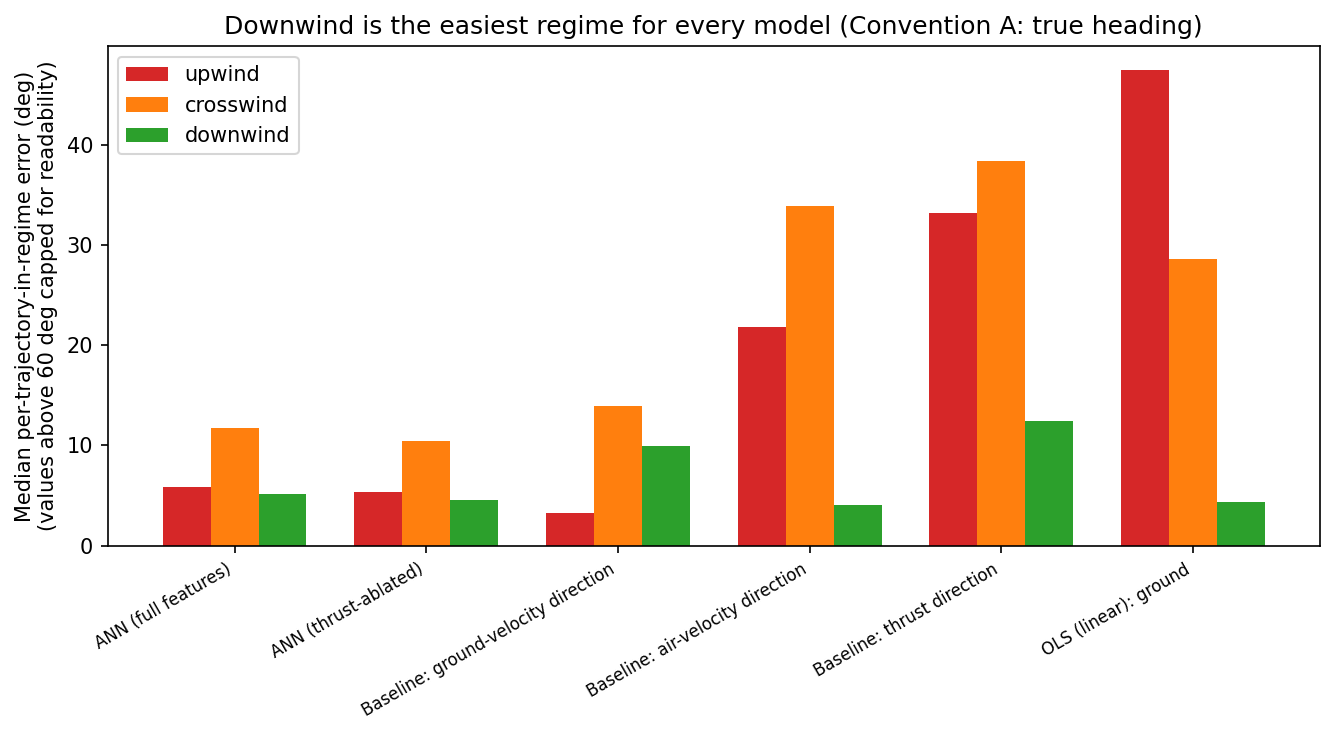

In [11]:
PLOT_MODELS = [
    'ANN (full features)',
    'ANN (thrust-ablated)',
    'Baseline: ground-velocity direction',
    'Baseline: air-velocity direction',
    'Baseline: thrust direction',
    'OLS (linear): ground',
]
regimes = ['upwind', 'crosswind', 'downwind']
colors = {'upwind': 'tab:red', 'crosswind': 'tab:orange', 'downwind': 'tab:green'}

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
x = np.arange(len(PLOT_MODELS))
width = 0.25
for i, regime in enumerate(regimes):
    values = [min(table_by_heading.loc[m, regime], 60) for m in PLOT_MODELS]  # cap for readability
    ax.bar(x + (i - 1) * width, values, width, label=regime, color=colors[regime])
ax.set_xticks(x)
ax.set_xticklabels(PLOT_MODELS, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Median per-trajectory-in-regime error (deg)\n(values above 60 deg capped for readability)')
ax.set_title('Downwind is the easiest regime for every model (Convention A: true heading)')
ax.legend()
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part3_directional_breakdown.svg', format='svg')
plt.show()

## 8. Summary

Both tables are saved to `pipelinedata/reviewer_response/directional_breakdown_by_heading.csv`
and `..._by_travel_direction.csv`. Read them together with the convention discussion in
Section 1: whichever matches the manuscript's intended meaning of "headed downwind" is
the one to cite when addressing Reviewer #1's downwind claim - the two conventions can
disagree markedly for any model whose error is sensitive to slip (heading != direction
of travel), which is precisely the phenomenon this paper's whole model is built to
capture.